# Notebook 08 — Reference-Based Calibration of Synthetic CLD / CHO Realism

## Goal

Notebook08 evaluates whether the synthetic CLD / CHO data generated in this project falls within biologically plausible reference ranges.

This notebook does **not** train a new ML model.

Instead, it asks:

> Does the synthetic data look realistic enough to support downstream ML and decision-engine experiments?

---

## Why this notebook matters

Earlier notebooks built:

- synthetic CLD generator
- feature engineering
- late-stage prediction models
- rescue-aware decision engine
- clone × process action recommendation

However, all of these depend on the realism of the synthetic data.

If the synthetic generator is too clean, too predictable, or too narrow, the ML pipeline may appear stronger than it would on real CHO / CLD data.

Notebook08 is the first calibration layer.

---

## Calibration strategy

We compare synthetic outputs against literature-informed CHO / NISTCHO reference ranges for:

- titer / productivity
- viable cell density
- viability
- aggregation
- qP drop / stability
- early-to-late predictability
- aggressive false-positive prevalence

---

## Interpretation

A mismatch is not a failure.

A mismatch tells us which part of the generator should be tuned next.

## Reference basis for Notebook08

Notebook08 uses public CHO / NISTCHO references as a scientific anchor for synthetic data calibration.

The goal is not to train directly on NISTCHO data in this first version.

Instead, the goal is to ask:

> Are the synthetic CLD / CHO distributions broadly consistent with published CHO reference systems?

---

### 1. NISTCHO reference cell line development paper

**Reference:**  
Development and Characterization of the NISTCHO Reference Cell Line

This paper describes the development and characterization of NISTCHO, a recombinant CHO cell line expressing a non-originator version of the NISTmAb IgG1.

In Notebook08, this reference supports the biological context for using NISTCHO as a CHO reference system.

**How it is used here:**

- define what NISTCHO is
- justify NISTCHO as an industry-relevant CHO reference cell line
- connect synthetic CLD simulation to a real CHO reference system
- provide context for growth, productivity, and product-quality characterization

---

### 2. NIST RM 8675 reference material certificate

**Reference:**  
NIST RM 8675 — NISTCHO, Clonal CHO-K1 Cell Line Producing cNISTmAb

The RM 8675 certificate describes NISTCHO as a publicly accessible, industry-relevant monoclonal antibody-expressing CHO-K1 lineage reference material.

It also states that RM 8675 can be used for biomanufacturing research and development, including evaluation of bioprocess measurement systems and bioprocess technologies associated with monoclonal antibody production.

In Notebook08, this reference supports why NISTCHO is a suitable calibration anchor.

**How it is used here:**

- justify why NISTCHO is relevant for bioprocess realism checks
- support comparison of synthetic CHO process ranges against public reference material context
- provide a formal reference basis for calibration language in the project

---

### 3. NISTCHO process development paper

**Reference:**  
Process development for production of non-originator NISTmAb from NISTCHO

This paper uses NISTCHO in upstream process development, including fed-batch and perfusion process contexts.

In Notebook08, this reference supports calibration of process-relevant synthetic outputs.

**How it is used here:**

- titer / productivity range context
- cell growth and VCD context
- viability behavior context
- upstream process variability context
- future calibration of process-aware simulation assumptions in Notebook07

---

### 4. CHOmics and future omics expansion

**Reference:**  
CHOmics and related CHO multi-omics resources

CHO multi-omics resources are not directly used in Notebook08 v1.

However, they are important for future extensions of this project.

Potential future uses:

- transcriptomics → identify genes associated with productivity, stability, stress response, and CRISPR intervention targets
- proteomics → evaluate secretion burden, folding stress, and pathway-level production bottlenecks
- metabolomics → connect clone behavior to media/feed optimization and metabolic byproduct control
- glycomics / glycoprofiling → connect upstream culture conditions to downstream product quality and QC strategy

These future extensions would support the long-term SDL vision:

> clone selection → process optimization → omics-guided intervention → product-quality-aware decision engine

---

## Scope of Notebook08 v1

Notebook08 v1 is a literature/reference-range calibration notebook.

It does not yet perform direct raw NISTCHO dataset modeling.

The role of this notebook is to create the first synthetic realism scorecard.

Future versions can expand as follows:

- **v1:** literature / reference range calibration
- **v2:** direct public dataset comparison
- **v3:** real CDMO calibration
- **v4:** omics-aware calibration and intervention modeling

## Step 1 — Load synthetic data

We load the synthetic datasets produced by earlier notebooks.

The most important files are:

- raw longitudinal synthetic CLD data
- processed feature / label table
- Notebook03 prediction table
- latent truth table

Together these allow us to evaluate:

- raw assay ranges
- engineered target ranges
- early-to-late predictability
- aggressive subgroup prevalence

In [1]:
# --------------------------------------------------
# Step 1 — Load synthetic data
# --------------------------------------------------

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr, ks_2samp, wasserstein_distance

scenario = "legacy"   # "legacy" or "optimized"
n_clones = 5000

DB_PATH = Path("../data/synthetic/raw") / f"cld_{n_clones}clones_{scenario}.db"
LATENT_PATH = Path("../data/synthetic/raw") / f"clone_latent_truths_{n_clones}_{scenario}.csv"
BATCH_PATH = Path("../data/synthetic/raw") / f"batch_effects_truths_{n_clones}_{scenario}.csv"

FEATURE_PATH = Path("../data/synthetic/processed") / (
    f"cld_features_with_labels_qp_targets_v2_24_30_{n_clones}_{scenario}.csv"
)

PRED_PATH = Path("../data/synthetic/processed") / (
    f"predictions_03b_qp_{n_clones}_{scenario}.csv"
)

print("Loading files:")
print("DB_PATH:", DB_PATH)
print("LATENT_PATH:", LATENT_PATH)
print("BATCH_PATH:", BATCH_PATH)
print("FEATURE_PATH:", FEATURE_PATH)
print("PRED_PATH:", PRED_PATH)

# Load SQLite tables
with sqlite3.connect(DB_PATH) as conn:
    passage = pd.read_sql_query("SELECT * FROM passage", conn)
    process_condition = pd.read_sql_query("SELECT * FROM process_condition", conn)
    assay_result = pd.read_sql_query("SELECT * FROM assay_result", conn)
    stability_test = pd.read_sql_query("SELECT * FROM stability_test", conn)

# Load CSV outputs
latent = pd.read_csv(LATENT_PATH)
batch = pd.read_csv(BATCH_PATH)
features = pd.read_csv(FEATURE_PATH)
pred = pd.read_csv(PRED_PATH)

print("\nShapes:")
print("passage:", passage.shape)
print("process_condition:", process_condition.shape)
print("assay_result:", assay_result.shape)
print("stability_test:", stability_test.shape)
print("latent:", latent.shape)
print("batch:", batch.shape)
print("features:", features.shape)
print("pred:", pred.shape)

# Build raw long table by joining assay results to passage metadata
raw_long = (
    assay_result
    .merge(passage, on="passage_id", how="left")
    .merge(process_condition, on="passage_id", how="left")
)

# Build raw wide table: one row per clone × passage
raw = (
    raw_long
    .pivot_table(
        index=["clone_id", "passage_id", "passage_number", "phase"],
        columns="assay_type",
        values="value",
        aggfunc="mean"
    )
    .reset_index()
)

raw.columns.name = None

print("\nConstructed raw calibration table:")
print("raw_long:", raw_long.shape)
print("raw wide:", raw.shape)

display(raw.head())
display(features.head())
display(pred.head())

Loading files:
DB_PATH: ../data/synthetic/raw/cld_5000clones_legacy.db
LATENT_PATH: ../data/synthetic/raw/clone_latent_truths_5000_legacy.csv
BATCH_PATH: ../data/synthetic/raw/batch_effects_truths_5000_legacy.csv
FEATURE_PATH: ../data/synthetic/processed/cld_features_with_labels_qp_targets_v2_24_30_5000_legacy.csv
PRED_PATH: ../data/synthetic/processed/predictions_03b_qp_5000_legacy.csv

Shapes:
passage: (150000, 5)
process_condition: (150000, 7)
assay_result: (605000, 7)
stability_test: (5000, 7)
latent: (5000, 20)
batch: (30, 5)
features: (5000, 57)
pred: (1000, 20)

Constructed raw calibration table:
raw_long: (605000, 17)
raw wide: (150000, 9)


,clone_id,passage_id,passage_number,phase,aggregation,ddpcr_cn,titer,vcd,viability
0,CLONE_0001,CLONE_0001_P01,1,early,5.464017,NaN,3.611143,9.786417e+06,92.333401
1,CLONE_0001,CLONE_0001_P02,2,early,5.903159,NaN,3.959182,9.608601e+06,95.034629
2,CLONE_0001,CLONE_0001_P03,3,early,5.641781,4.0,3.478151,1.118005e+07,93.043137
3,CLONE_0001,CLONE_0001_P04,4,early,5.960226,NaN,3.646983,1.035721e+07,93.554481
4,CLONE_0001,CLONE_0001_P05,5,early,6.105156,NaN,3.185749,1.158315e+07,94.415453


,clone_id,titer_mean,titer_std,titer_min,titer_max,titer_cv,titer_p10,vcd_mean,vcd_std,vcd_min,...,qP_proxy_slope,qP_proxy_slope_3_6,qP_proxy_slope_7_10,qP_proxy_curvature,ddpcr_cn,early_mean_qp,late_mean_qp,late_mean_aggregation,qp_drop_pct,stable_label_30pct
0,CLONE_0001,3.240001,0.244658,2.946003,3.646983,0.075512,3.116997,1.150399e+07,8.543827e+05,1.035721e+07,...,-1.268820e-08,-8.441910e-09,-9.485069e-09,-1.043159e-09,4.0,2.840245e-07,1.685610e-07,6.532632,0.406525,0
1,CLONE_0002,0.890732,0.199584,0.492907,1.080938,0.224068,1.042496,1.436123e+07,8.165488e+05,1.312061e+07,...,-7.610942e-10,5.152232e-11,9.430391e-09,9.378869e-09,2.0,6.264352e-08,2.327035e-08,9.320724,0.628517,0
2,CLONE_0003,5.060018,0.403075,4.469948,5.464666,0.079659,4.596945,7.826375e+06,2.751202e+05,7.427478e+06,...,-2.476998e-08,2.694125e-09,-3.703065e-08,-3.972477e-08,5.0,6.481282e-07,1.766731e-07,4.421152,0.727409,0
3,CLONE_0004,1.223941,0.316260,0.668985,1.593312,0.258395,0.668985,1.562601e+07,1.721244e+06,1.305176e+07,...,-1.083020e-08,-9.071218e-09,-8.397878e-09,6.733401e-10,4.0,8.064730e-08,2.386570e-08,2.158328,0.704064,0
4,CLONE_0005,3.254988,0.137416,3.048111,3.434989,0.042217,3.144411,1.021871e+07,1.226798e+06,8.845936e+06,...,-1.193248e-08,-1.310922e-08,-2.204084e-08,-8.931621e-09,6.0,3.230290e-07,1.898780e-07,2.565377,0.412194,0


,clone_id,pred_qp_drop,pred_late_qp,pred_late_agg,pred_stable_prob,pred_stable_label,true_qp_drop,true_late_qp,true_late_agg,true_stable_label,pred_super_prob,pred_aggr_prob,true_is_aggressive,rescue_upside_qp,rescue_stability_band,rescue_quality_band,rescue_aggressive_penalty,rescue_not_already_pass,pred_rescue_score,pred_rescue_label
0,CLONE_1502,0.381373,2.711177e-08,9.583127,0.370940,0,0.111023,4.176362e-08,12.566994,1,0.000000,0.024314,0,0.000518,0.895422,0.803068,0.974885,0.486344,0.598822,1
1,CLONE_2587,0.489493,6.445184e-08,3.127400,0.169707,0,0.691891,3.691256e-08,0.918511,0,0.000000,0.001179,0,0.007290,0.535023,0.000000,0.998782,0.769478,0.264869,0
2,CLONE_2654,0.362087,3.071979e-08,7.313653,0.492969,0,0.009193,4.002863e-08,6.558486,1,0.004355,0.014202,0,0.001172,0.959708,0.661044,0.985331,0.314649,0.571715,0
3,CLONE_1056,0.353752,6.793292e-08,6.868662,0.478848,0,0.708930,3.026369e-08,7.990409,0,0.004891,0.001310,0,0.007922,0.987492,0.533903,0.998647,0.334518,0.549744,0
4,CLONE_0706,0.616517,1.729449e-07,8.278383,0.036653,0,0.740570,1.029717e-07,7.441547,0,0.012486,0.072412,0,0.026969,0.111609,0.936681,0.925203,0.956685,0.397218,0


## Step 2 — Inspect available columns

Synthetic generators evolve over time.

Before calibration, we inspect column names so the notebook can map available synthetic fields to calibration metrics.

In [2]:
# --------------------------------------------------
# Step 2 — Inspect available columns
# --------------------------------------------------

print("=== Raw columns ===")
print(raw.columns.tolist())

print("\n=== Feature columns ===")
print(features.columns.tolist())

print("\n=== Prediction columns ===")
print(pred.columns.tolist())

print("\n=== Latent columns ===")
print(latent.columns.tolist())

=== Raw columns ===
['clone_id', 'passage_id', 'passage_number', 'phase', 'aggregation', 'ddpcr_cn', 'titer', 'vcd', 'viability']

=== Feature columns ===
['clone_id', 'titer_mean', 'titer_std', 'titer_min', 'titer_max', 'titer_cv', 'titer_p10', 'vcd_mean', 'vcd_std', 'vcd_min', 'vcd_max', 'vcd_cv', 'vcd_p10', 'viability_mean', 'viability_std', 'viability_min', 'viability_max', 'viability_cv', 'viability_p10', 'aggregation_mean', 'aggregation_std', 'aggregation_min', 'aggregation_max', 'aggregation_cv', 'aggregation_p10', 'qP_proxy_mean', 'qP_proxy_std', 'qP_proxy_min', 'qP_proxy_max', 'qP_proxy_cv', 'qP_proxy_p10', 'titer_slope', 'titer_slope_3_6', 'titer_slope_7_10', 'titer_curvature', 'vcd_slope', 'vcd_slope_3_6', 'vcd_slope_7_10', 'vcd_curvature', 'viability_slope', 'viability_slope_3_6', 'viability_slope_7_10', 'viability_curvature', 'aggregation_slope', 'aggregation_slope_3_6', 'aggregation_slope_7_10', 'aggregation_curvature', 'qP_proxy_slope', 'qP_proxy_slope_3_6', 'qP_proxy_sl

## Step 3 — Define literature-informed reference ranges

Notebook08 v1 does not load raw NISTCHO time-course data.

Instead, it defines broad reference ranges manually from public CHO / NISTCHO literature and reference-material documentation.

These ranges act as a first-pass calibration anchor.

Future Notebook08 v2 can replace this manually curated table with direct public dataset loading.

In [3]:
# NOTE:
# Notebook08 v1 does not fetch raw NISTCHO experimental data.
# The dataframe below is a manually curated reference-range table
# based on public CHO / NISTCHO literature and reference-material documentation.
#
# In Notebook08 v2, this section can be replaced by:
# - loading supplementary CSV/XLSX files from NISTCHO publications
# - loading public omics/process datasets
# - loading real CDMO calibration data

# --------------------------------------------------
# Step 3 — Literature-informed reference ranges
# --------------------------------------------------
# These are broad calibration ranges.
# They are not strict pass/fail criteria.
#
# Units depend on the synthetic generator:
# - viability may be fraction 0–1 or percent 0–100
# - titer/qP may be synthetic-scale values
# Therefore this notebook focuses first on distribution shape,
# variability, and plausibility flags.

reference_ranges = pd.DataFrame([
    {
        "metric": "viability_fraction",
        "expected_min": 0.70,
        "expected_max": 0.99,
        "calibration_note": "CHO fed-batch viability often remains high but should not be nearly variance-free.",
    },
    {
        "metric": "late_aggregation_percent",
        "expected_min": 0.0,
        "expected_max": 20.0,
        "calibration_note": "Aggregation should have a meaningful quality-risk tail.",
    },
    {
        "metric": "qp_drop_fraction",
        "expected_min": 0.0,
        "expected_max": 0.90,
        "calibration_note": "Stability loss should vary substantially across clones.",
    },
    {
        "metric": "early_late_spearman",
        "expected_min": 0.45,
        "expected_max": 0.75,
        "calibration_note": "Early-to-late ranking should be useful but imperfect.",
    },
    {
        "metric": "aggressive_prevalence",
        "expected_min": 0.005,
        "expected_max": 0.10,
        "calibration_note": "Aggressive false-positive subgroup should be rare but detectable.",
    },
])

display(reference_ranges)

,metric,expected_min,expected_max,calibration_note
0,viability_fraction,0.700,0.99,CHO fed-batch viability often remains high but...
1,late_aggregation_percent,0.000,20.00,Aggregation should have a meaningful quality-r...
2,qp_drop_fraction,0.000,0.90,Stability loss should vary substantially acros...
3,early_late_spearman,0.450,0.75,Early-to-late ranking should be useful but imp...
4,aggressive_prevalence,0.005,0.10,Aggressive false-positive subgroup should be r...


## Step 4 — Extract synthetic calibration metrics

We compute synthetic metrics that can be compared to reference expectations.

This includes:

- raw assay ranges
- late target distributions
- subgroup prevalence
- early-to-late ranking correlation

The goal is not to prove the synthetic data is perfect.

The goal is to identify where the generator is too optimistic, too narrow, or too noisy.

In [4]:
# --------------------------------------------------
# Step 4 — Extract synthetic calibration metrics
# --------------------------------------------------

def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

# Raw wide columns generated from SQLite assay_result pivot
clone_col = find_col(raw, ["clone_id"])
passage_col = find_col(raw, ["passage_number", "passage"])
titer_col = find_col(raw, ["titer"])
vcd_col = find_col(raw, ["vcd"])
viab_col = find_col(raw, ["viability"])
agg_col_raw = find_col(raw, ["aggregation"])
cn_raw_col = find_col(raw, ["ddpcr_cn"])

print("Mapped raw columns:")
print("clone_col:", clone_col)
print("passage_col:", passage_col)
print("titer_col:", titer_col)
print("vcd_col:", vcd_col)
print("viab_col:", viab_col)
print("agg_col_raw:", agg_col_raw)
print("cn_raw_col:", cn_raw_col)

# Feature/target columns
late_qp_col = find_col(features, ["late_mean_qp", "late_qp", "late_mean_titer"])
drop_col = find_col(features, ["qp_drop_pct", "productivity_drop_pct"])
late_agg_col = find_col(features, ["late_mean_aggregation", "late_agg"])

print("\nMapped feature target columns:")
print("late_qp_col:", late_qp_col)
print("drop_col:", drop_col)
print("late_agg_col:", late_agg_col)

# Latent subgroup / biology columns
aggr_col = find_col(latent, ["is_aggressive", "aggressive"])
super_col = find_col(latent, ["is_super", "super"])
cn_true_col = find_col(latent, ["CN_true"])
cn_obs_col = find_col(latent, ["CN_obs"])
productivity_col = find_col(latent, ["productivity"])
stability_col = find_col(latent, ["stability"])
quality_col = find_col(latent, ["quality_potential"])

print("\nMapped latent columns:")
print("aggr_col:", aggr_col)
print("super_col:", super_col)
print("cn_true_col:", cn_true_col)
print("cn_obs_col:", cn_obs_col)
print("productivity_col:", productivity_col)
print("stability_col:", stability_col)
print("quality_col:", quality_col)

Mapped raw columns:
clone_col: clone_id
passage_col: passage_number
titer_col: titer
vcd_col: vcd
viab_col: viability
agg_col_raw: aggregation
cn_raw_col: ddpcr_cn

Mapped feature target columns:
late_qp_col: late_mean_qp
drop_col: qp_drop_pct
late_agg_col: late_mean_aggregation

Mapped latent columns:
aggr_col: is_aggressive
super_col: is_super
cn_true_col: CN_true
cn_obs_col: CN_obs
productivity_col: productivity
stability_col: stability
quality_col: quality_potential


## Step 5 — Summary statistics

This step summarizes the synthetic distributions.

We look for obvious red flags:

- very narrow standard deviation
- unrealistic min/max values
- extreme skew
- too-small quality-risk tail

In [5]:
# --------------------------------------------------
# Step 5 — Summary statistics
# --------------------------------------------------

summary_rows = []

def add_summary(name, series):
    s = pd.Series(series).dropna().astype(float)

    if len(s) == 0:
        return

    summary_rows.append({
        "metric": name,
        "n": len(s),
        "mean": float(s.mean()),
        "std": float(s.std()),
        "min": float(s.min()),
        "p01": float(s.quantile(0.01)),
        "p05": float(s.quantile(0.05)),
        "p25": float(s.quantile(0.25)),
        "p50": float(s.quantile(0.50)),
        "p75": float(s.quantile(0.75)),
        "p95": float(s.quantile(0.95)),
        "p99": float(s.quantile(0.99)),
        "max": float(s.max()),
    })

# -----------------------------
# Raw assay distributions
# -----------------------------
if titer_col:
    add_summary("raw_titer", raw[titer_col])

if vcd_col:
    add_summary("raw_vcd", raw[vcd_col])

if viab_col:
    add_summary("raw_viability", raw[viab_col])

if agg_col_raw:
    add_summary("raw_aggregation", raw[agg_col_raw])

if cn_raw_col:
    add_summary("raw_ddpcr_cn", raw[cn_raw_col])

# -----------------------------
# Processed target distributions
# -----------------------------
if late_qp_col:
    add_summary("late_mean_qp", features[late_qp_col])

if drop_col:
    add_summary("qp_drop_pct", features[drop_col])

if late_agg_col:
    add_summary("late_mean_aggregation", features[late_agg_col])

# -----------------------------
# Latent truth distributions
# These are not deployment features.
# They are used only for simulator calibration.
# -----------------------------
if cn_true_col:
    add_summary("latent_CN_true", latent[cn_true_col])

if cn_obs_col:
    add_summary("latent_CN_obs", latent[cn_obs_col])

if productivity_col:
    add_summary("latent_productivity", latent[productivity_col])

if stability_col:
    add_summary("latent_stability", latent[stability_col])

if quality_col:
    add_summary("latent_quality_potential", latent[quality_col])

if aggr_col:
    add_summary("latent_is_aggressive", latent[aggr_col])

if super_col:
    add_summary("latent_is_super", latent[super_col])

synthetic_summary = pd.DataFrame(summary_rows)

print("=== Synthetic calibration summary ===")
display(synthetic_summary)

=== Synthetic calibration summary ===


,metric,n,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,raw_titer,150000,2.158855e+00,2.150833e+00,0.000000e+00,7.753079e-02,3.693894e-01,9.355272e-01,1.593710e+00,2.660802e+00,5.699725e+00,1.083899e+01,5.536903e+01
1,raw_vcd,150000,1.377533e+07,3.112933e+06,0.000000e+00,4.845578e+06,8.253514e+06,1.196117e+07,1.403097e+07,1.588009e+07,1.838139e+07,2.019045e+07,2.693398e+07
2,raw_viability,150000,9.659376e+01,2.262218e+00,6.615790e+01,9.001541e+01,9.271065e+01,9.527443e+01,9.680628e+01,9.820845e+01,1.000000e+02,1.000000e+02,1.000000e+02
3,raw_aggregation,150000,5.859650e+00,3.097245e+00,0.000000e+00,0.000000e+00,1.303991e+00,3.637567e+00,5.665803e+00,7.802238e+00,1.103731e+01,1.453769e+01,2.968728e+01
4,raw_ddpcr_cn,5000,3.336200e+00,1.619412e+00,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,6.000000e+00,9.000000e+00,1.500000e+01
5,late_mean_qp,5000,1.774095e-07,1.221753e-06,1.241834e-09,7.194483e-09,1.660393e-08,4.256207e-08,7.998417e-08,1.540462e-07,4.387143e-07,1.393410e-06,7.851137e-05
6,qp_drop_pct,5000,4.339171e-01,2.068495e-01,0.000000e+00,0.000000e+00,6.170623e-02,2.956524e-01,4.395514e-01,5.730864e-01,7.703447e-01,9.098045e-01,9.817109e-01
7,late_mean_aggregation,5000,6.158600e+00,3.281276e+00,0.000000e+00,5.459293e-01,1.294393e+00,3.599848e+00,5.917683e+00,8.379098e+00,1.196002e+01,1.434258e+01,1.930770e+01
8,latent_CN_true,5000,3.334000e+00,1.574846e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,6.000000e+00,8.010000e+00,1.500000e+01
9,latent_CN_obs,5000,3.336200e+00,1.619412e+00,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,6.000000e+00,9.000000e+00,1.500000e+01


## Step 6 — Distribution plots

We visualize the main synthetic distributions.

These plots help answer:

- Is the distribution too narrow?
- Is the tail biologically plausible?
- Are there extreme values?
- Does the synthetic data look overly clean?

Number of distributions to plot: 15


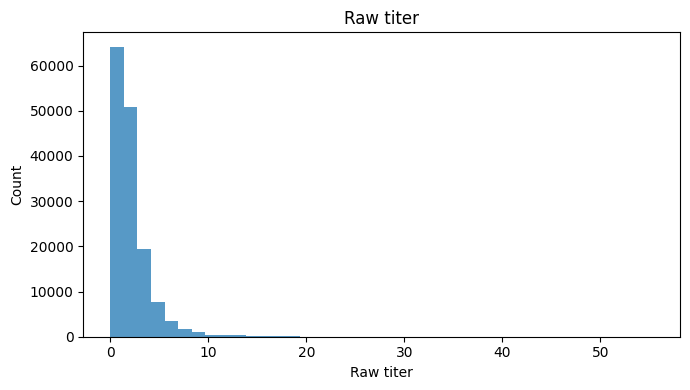

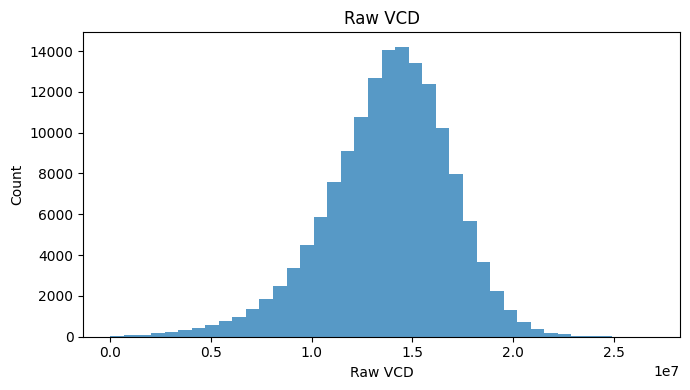

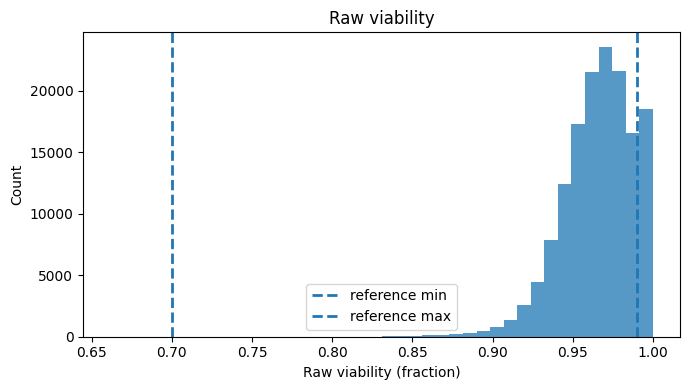

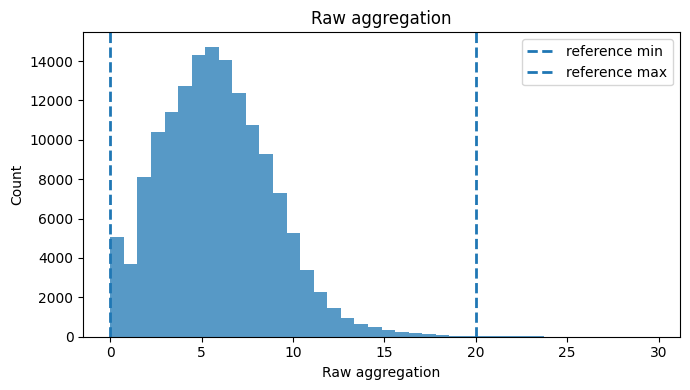

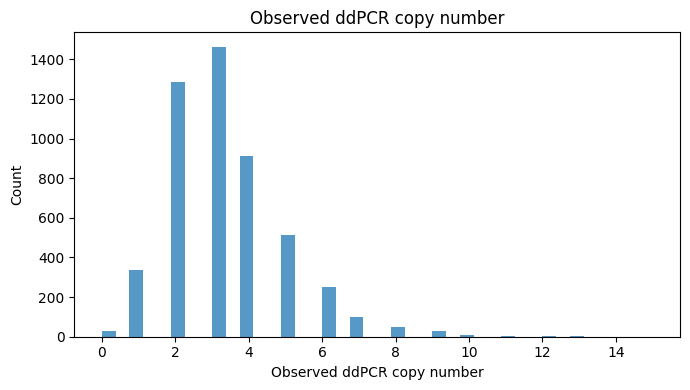

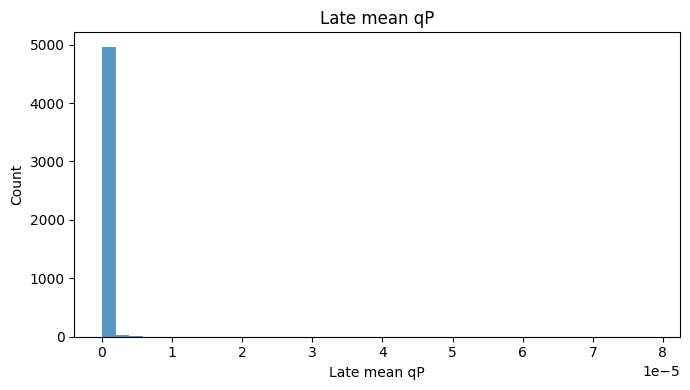

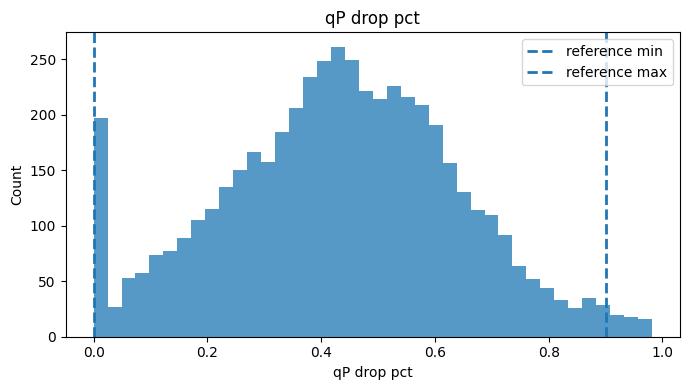

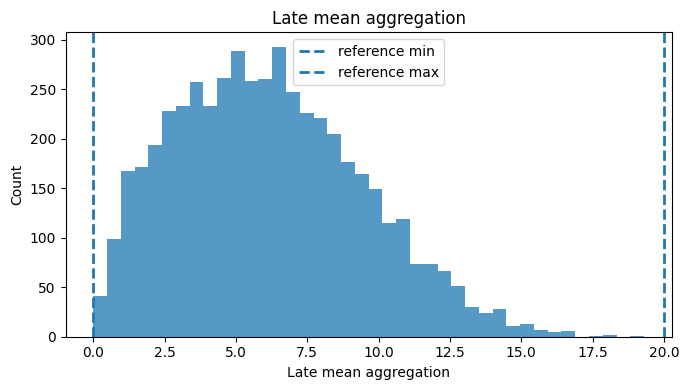

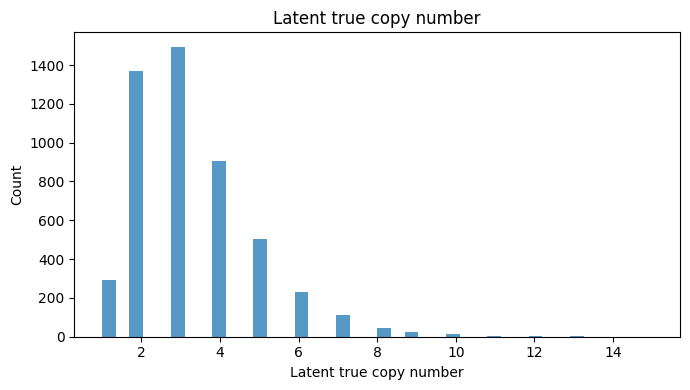

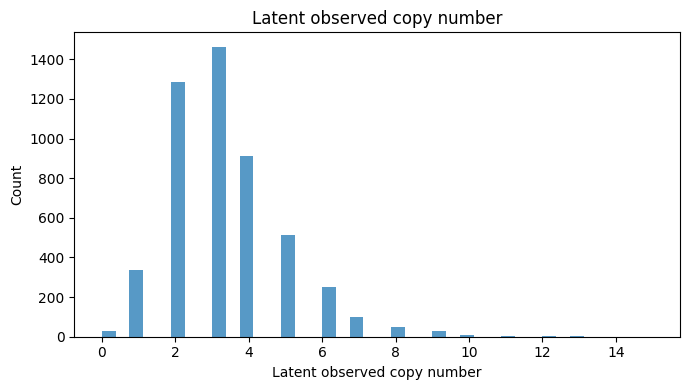

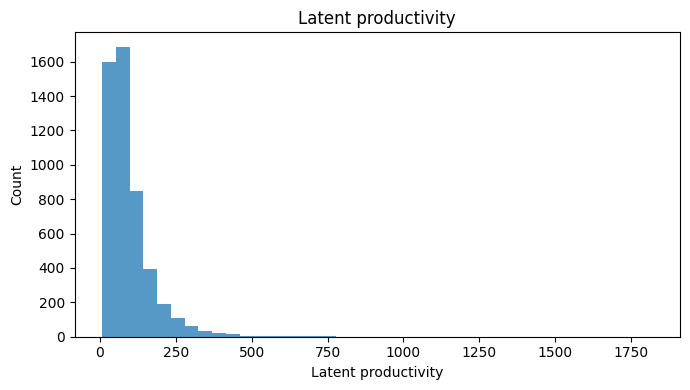

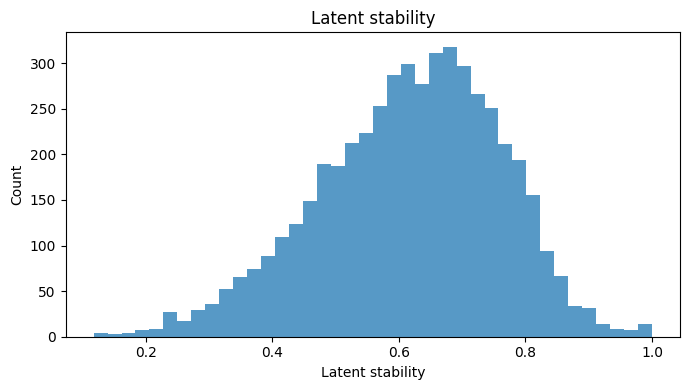

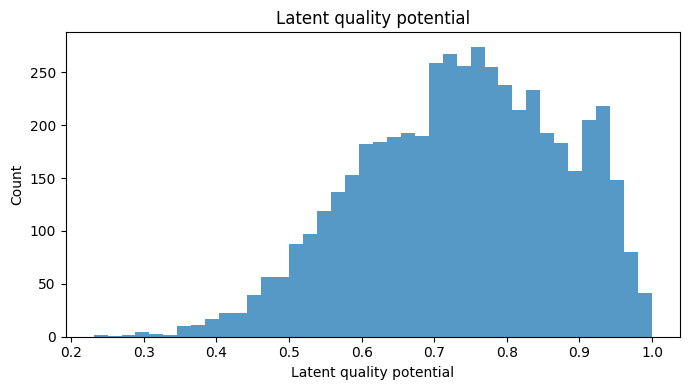

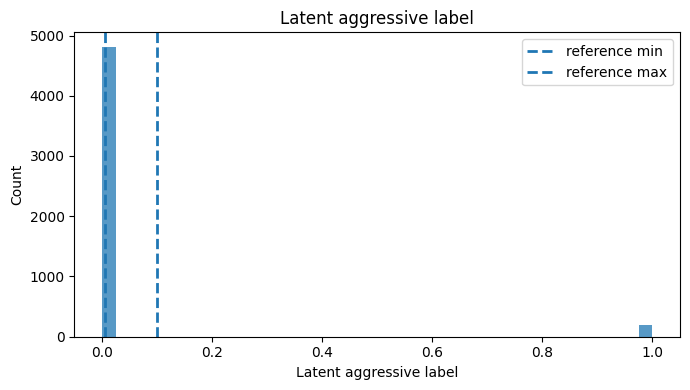

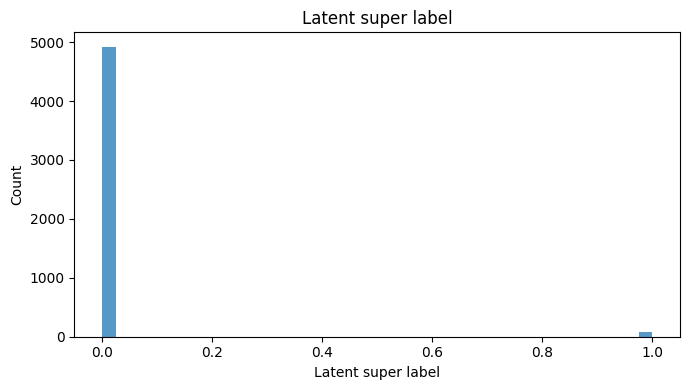

In [6]:
# --------------------------------------------------
# Step 6 — Distribution plots with reference range lines
# --------------------------------------------------

plot_items = []

# title, series, reference metric name
if titer_col:
    plot_items.append(("Raw titer", raw[titer_col], None))

if vcd_col:
    plot_items.append(("Raw VCD", raw[vcd_col], None))

if viab_col:
    plot_items.append(("Raw viability", raw[viab_col], "viability_fraction"))

if agg_col_raw:
    plot_items.append(("Raw aggregation", raw[agg_col_raw], "late_aggregation_percent"))

if cn_raw_col:
    plot_items.append(("Observed ddPCR copy number", raw[cn_raw_col], None))

if late_qp_col:
    plot_items.append(("Late mean qP", features[late_qp_col], None))

if drop_col:
    plot_items.append(("qP drop pct", features[drop_col], "qp_drop_fraction"))

if late_agg_col:
    plot_items.append(("Late mean aggregation", features[late_agg_col], "late_aggregation_percent"))

if cn_true_col:
    plot_items.append(("Latent true copy number", latent[cn_true_col], None))

if cn_obs_col:
    plot_items.append(("Latent observed copy number", latent[cn_obs_col], None))

if productivity_col:
    plot_items.append(("Latent productivity", latent[productivity_col], None))

if stability_col:
    plot_items.append(("Latent stability", latent[stability_col], None))

if quality_col:
    plot_items.append(("Latent quality potential", latent[quality_col], None))

if aggr_col:
    plot_items.append(("Latent aggressive label", latent[aggr_col], "aggressive_prevalence"))

if super_col:
    plot_items.append(("Latent super label", latent[super_col], None))

print("Number of distributions to plot:", len(plot_items))

def get_reference_range(metric_name):
    if metric_name is None:
        return None

    hit = reference_ranges[reference_ranges["metric"] == metric_name]

    if len(hit) == 0:
        return None

    row = hit.iloc[0]
    return float(row["expected_min"]), float(row["expected_max"])

for title, series, ref_metric in plot_items:
    s = pd.Series(series).dropna().astype(float)

    if len(s) == 0:
        continue

    # Convert viability percent to fraction only for plotting against reference
    plot_s = s.copy()
    xlabel = title

    if ref_metric == "viability_fraction" and plot_s.median() > 1.5:
        plot_s = plot_s / 100.0
        xlabel = title + " (fraction)"

    plt.figure(figsize=(7, 4))
    plt.hist(plot_s, bins=40, alpha=0.75)

    ref = get_reference_range(ref_metric)
    if ref is not None:
        ref_min, ref_max = ref
        plt.axvline(ref_min, linestyle="--", linewidth=2, label="reference min")
        plt.axvline(ref_max, linestyle="--", linewidth=2, label="reference max")
        plt.legend()

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

## Step 7 — Early-to-late predictability calibration

One of the most important realism checks is early-to-late predictability.

If early features predict late outcomes too well, the synthetic data may be too clean.

We calculate Spearman rank correlation between early-stage proxy features and late-stage outcomes.

In [7]:
# --------------------------------------------------
# Step 7 — Early-to-late predictability calibration
# --------------------------------------------------

early_candidates = [
    "qP_proxy_mean",
    "qP_mean",
    "titer_mean",
    "titer_p90",
    "titer_slope",
    "vcd_mean",
    "viability_mean",
]

late_targets = {
    "late_mean_qp": late_qp_col,
    "qp_drop_pct": drop_col,
    "late_mean_aggregation": late_agg_col,
}

spearman_rows = []

for early_col in early_candidates:
    if early_col not in features.columns:
        continue

    for target_name, target_col in late_targets.items():
        if target_col is None or target_col not in features.columns:
            continue

        rho = spearmanr(features[early_col], features[target_col]).correlation

        spearman_rows.append({
            "early_feature": early_col,
            "late_target": target_name,
            "spearman_rho": float(rho),
            "abs_spearman": float(abs(rho)),
        })

spearman_df = (
    pd.DataFrame(spearman_rows)
    .sort_values("abs_spearman", ascending=False)
    .reset_index(drop=True)
)

display(spearman_df)

,early_feature,late_target,spearman_rho,abs_spearman
0,qP_proxy_mean,late_mean_qp,0.887192,0.887192
1,titer_mean,late_mean_qp,0.874634,0.874634
2,vcd_mean,late_mean_qp,-0.800800,0.800800
3,viability_mean,late_mean_qp,-0.766842,0.766842
4,titer_slope,qp_drop_pct,-0.459459,0.459459
5,titer_slope,late_mean_qp,-0.308185,0.308185
6,titer_mean,qp_drop_pct,0.125350,0.125350
7,qP_proxy_mean,qp_drop_pct,0.118867,0.118867
8,vcd_mean,qp_drop_pct,-0.079284,0.079284
9,viability_mean,qp_drop_pct,-0.053958,0.053958


## Step 8 — Calibration scorecard

This scorecard converts distribution checks into a simple diagnostic table.

Each metric is classified as:

- within broad reference range
- below expected range
- above expected range
- needs review

This is not a regulatory validation.

It is a synthetic realism diagnostic.

In [8]:
# --------------------------------------------------
# Step 8 — Calibration scorecard
# --------------------------------------------------

score_rows = []

def range_check(metric, value, expected_min, expected_max, note):
    if pd.isna(value):
        status = "missing"
    elif value < expected_min:
        status = "below expected"
    elif value > expected_max:
        status = "above expected"
    else:
        status = "within broad range"

    score_rows.append({
        "metric": metric,
        "synthetic_value": value,
        "expected_min": expected_min,
        "expected_max": expected_max,
        "status": status,
        "note": note,
    })

# Viability: convert if needed
if viab_col:
    viab = raw[viab_col].dropna().astype(float)
    viab_median = viab.median()

    if viab_median > 1.5:
        viab_for_check = viab / 100.0
    else:
        viab_for_check = viab

    range_check(
        "viability_fraction_p05",
        float(viab_for_check.quantile(0.05)),
        0.70,
        0.99,
        "Low-tail viability should be plausible; too high may indicate overly clean simulation.",
    )

# Late aggregation
if late_agg_col:
    late_agg = features[late_agg_col].dropna().astype(float)

    range_check(
        "late_aggregation_p95",
        float(late_agg.quantile(0.95)),
        2.0,
        20.0,
        "Aggregation p95 should show a meaningful quality-risk tail.",
    )

# qP drop
if drop_col:
    drop = features[drop_col].dropna().astype(float)

    range_check(
        "qp_drop_p95",
        float(drop.quantile(0.95)),
        0.20,
        0.90,
        "qP drop p95 should show stability failure risk.",
    )

# Aggressive prevalence
if aggr_col:
    aggr_prev = float(latent[aggr_col].mean())

    range_check(
        "aggressive_prevalence",
        aggr_prev,
        0.005,
        0.10,
        "Aggressive false-positive subgroup should be rare but detectable.",
    )

# Early-late strongest Spearman
if len(spearman_df) > 0:
    max_abs_rho = float(spearman_df["abs_spearman"].max())

    range_check(
        "max_abs_early_late_spearman",
        max_abs_rho,
        0.30,
        0.80,
        "Too high suggests synthetic early-late relationships may be overly clean.",
    )

calibration_scorecard = pd.DataFrame(score_rows)
display(calibration_scorecard)

,metric,synthetic_value,expected_min,expected_max,status,note
0,viability_fraction_p05,0.927107,0.700,0.99,within broad range,Low-tail viability should be plausible; too hi...
1,late_aggregation_p95,11.960021,2.000,20.00,within broad range,Aggregation p95 should show a meaningful quali...
2,qp_drop_p95,0.770345,0.200,0.90,within broad range,qP drop p95 should show stability failure risk.
3,aggressive_prevalence,0.037600,0.005,0.10,within broad range,Aggressive false-positive subgroup should be r...
4,max_abs_early_late_spearman,0.887192,0.300,0.80,above expected,Too high suggests synthetic early-late relatio...


## Step 9 — Generator tuning recommendations

This step translates calibration results into generator tuning recommendations.

The goal is to identify which assumptions should be adjusted next.

In [9]:
# --------------------------------------------------
# Step 9 — Generator tuning recommendations
# --------------------------------------------------

recommendations = []

for _, row in calibration_scorecard.iterrows():
    metric = row["metric"]
    status = row["status"]
    value = row["synthetic_value"]

    if metric == "max_abs_early_late_spearman" and status == "above expected":
        recommendations.append({
            "issue": "Early-to-late predictability too strong",
            "evidence": f"{metric} = {value:.3f}",
            "recommendation": "Increase hidden late-only noise, epigenetic drift, and clone-specific stochasticity.",
            "priority": "High",
        })

    if metric == "late_aggregation_p95" and status == "below expected":
        recommendations.append({
            "issue": "Aggregation risk tail too weak",
            "evidence": f"{metric} = {value:.3f}",
            "recommendation": "Increase aggregation heterogeneity and stress-linked aggregation noise.",
            "priority": "Medium",
        })

    if metric == "qp_drop_p95" and status == "below expected":
        recommendations.append({
            "issue": "Stability failure tail too weak",
            "evidence": f"{metric} = {value:.3f}",
            "recommendation": "Increase productivity decay heterogeneity and late-stage instability.",
            "priority": "High",
        })

    if metric == "viability_fraction_p05" and status == "above expected":
        recommendations.append({
            "issue": "Viability distribution too clean",
            "evidence": f"{metric} = {value:.3f}",
            "recommendation": "Increase batch/process noise and clone-specific viability stress.",
            "priority": "Medium",
        })

    if metric == "aggressive_prevalence" and status == "below expected":
        recommendations.append({
            "issue": "Aggressive subgroup too rare",
            "evidence": f"{metric} = {value:.3f}",
            "recommendation": "Increase residual aggressive subgroup prevalence or relax aggressive label criteria.",
            "priority": "Medium",
        })

    if metric == "aggressive_prevalence" and status == "above expected":
        recommendations.append({
            "issue": "Aggressive subgroup too common",
            "evidence": f"{metric} = {value:.3f}",
            "recommendation": "Reduce aggressive subgroup prevalence to keep it rare and realistic.",
            "priority": "Medium",
        })

recommendation_df = pd.DataFrame(recommendations)

if len(recommendation_df) == 0:
    print("No major generator tuning recommendations triggered by broad calibration rules.")
else:
    display(recommendation_df)

,issue,evidence,recommendation,priority
0,Early-to-late predictability too strong,max_abs_early_late_spearman = 0.887,"Increase hidden late-only noise, epigenetic dr...",High


## Step 10 — Save calibration outputs

We save:

- synthetic summary statistics
- calibration scorecard
- generator tuning recommendations

These outputs can be used later when updating the generator.

In [10]:
# --------------------------------------------------
# Step 10 — Save calibration outputs
# --------------------------------------------------

OUT_DIR = Path("../reports")
OUT_DIR.mkdir(parents=True, exist_ok=True)

summary_path = OUT_DIR / f"notebook08_synthetic_summary_{n_clones}_{scenario}.csv"
scorecard_path = OUT_DIR / f"notebook08_calibration_scorecard_{n_clones}_{scenario}.csv"
recommendation_path = OUT_DIR / f"notebook08_generator_recommendations_{n_clones}_{scenario}.csv"

synthetic_summary.to_csv(summary_path, index=False)
calibration_scorecard.to_csv(scorecard_path, index=False)

if len(recommendation_df) > 0:
    recommendation_df.to_csv(recommendation_path, index=False)

print("Saved synthetic summary:", summary_path)
print("Saved calibration scorecard:", scorecard_path)

if len(recommendation_df) > 0:
    print("Saved generator recommendations:", recommendation_path)
else:
    print("No recommendation file saved because no major recommendations were triggered.")

Saved synthetic summary: ../reports/notebook08_synthetic_summary_5000_legacy.csv
Saved calibration scorecard: ../reports/notebook08_calibration_scorecard_5000_legacy.csv
Saved generator recommendations: ../reports/notebook08_generator_recommendations_5000_legacy.csv


## Final interpretation of Notebook08

Notebook08 is the first reference-calibration layer of the CLD ML Pipeline.

The goal is not to train a better model.

The goal is to evaluate whether the synthetic data generator produces biologically plausible CHO / CLD distributions.

---

## What this notebook checks

Notebook08 evaluates:

- raw assay distributions
- late-stage qP / productivity range
- qP drop / stability-loss range
- aggregation / quality-risk range
- aggressive false-positive prevalence
- early-to-late Spearman predictability

---

## Why this matters

If the synthetic data is too clean, then downstream ML performance may be overly optimistic.

If early-to-late Spearman correlation is too high, the model may look stronger than it would on real CHO data.

If quality or stability tails are too weak, the decision engine may underestimate real late-stage failure risk.

---

## Scientific reference context

Notebook08 is grounded in public CHO / NISTCHO references.

The NISTCHO reference cell line development paper establishes NISTCHO as a recombinant CHO reference system expressing a non-originator version of the NISTmAb IgG1.

The NIST RM 8675 certificate describes NISTCHO as a publicly accessible, industry-relevant monoclonal antibody-expressing CHO-K1 lineage reference material for biomanufacturing research and bioprocess measurement system evaluation.

The NISTCHO process development paper provides upstream process context for NISTCHO-based mAb production, including fed-batch and perfusion development.

In Notebook08 v1, these references are used to motivate broad biological realism checks rather than direct model training.

The calibration goal is:

> synthetic CLD / CHO distributions should be biologically plausible before downstream ML and SDL decisions are trusted.

---

## Current limitation

This notebook does not yet use full raw NISTCHO time-course data.

It should be interpreted as:

> v1 — literature/reference range calibration

Future versions should move toward:

1. direct public dataset comparison
2. omics-aware calibration
3. real CDMO calibration

---

## Next step

Use the calibration scorecard and generator recommendations to tune the synthetic generator.

The most important generator realism targets are:

- reduce overly strong early-to-late predictability if present
- widen copy-number and productivity heterogeneity if too narrow
- increase late-only stochasticity if ML performance is too optimistic
- ensure aggregation and stability failure tails are biologically plausible